In [2]:
pip install yfinance

  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 350.5 kB/s  0:00:08 eta 0:00:01
Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl (429 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [yfinance]/11 [yfinance]]t-py]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('All imports successful!')

All imports successful!


In [4]:
# Download stock price data for key tickers
tickers = ['AAPL', 'AMZN', 'GOOG', 'MSFT', 'TSLA']

# Download data from yfinance
raw_data = yf.download(tickers, start='2015-01-01', end='2020-06-11', group_by='ticker')

print(f'Downloaded data shape: {raw_data.shape}')
print(f'Columns: {raw_data.columns.tolist()[:10]}')
raw_data.head()

[*********************100%***********************]  5 of 5 completed

Downloaded data shape: (1369, 25)
Columns: [('MSFT', 'Open'), ('MSFT', 'High'), ('MSFT', 'Low'), ('MSFT', 'Close'), ('MSFT', 'Volume'), ('AAPL', 'Open'), ('AAPL', 'High'), ('AAPL', 'Low'), ('AAPL', 'Close'), ('AAPL', 'Volume')]


Ticker           MSFT                                                  AAPL  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2015-01-02  39.682636  40.328987  39.580581  39.767681  27913900  24.648441   
2015-01-05  39.436009  39.742176  39.333954  39.401993  39673900  23.962473   
2015-01-06  39.444511  39.759182  38.730122  38.823673  36447900  23.575232   
2015-01-07  39.104317  39.512539  38.687591  39.316933  29114100  23.721274   
2015-01-08  39.759178  40.609642  39.733665  40.473568  29645200  24.170477   

Ticker                                                  ...       TSLA  \
Price            High        Low      Close     Volume  ...       Open   
Date                                                    ...              
2015-01-02  24.659506  23.754468  24.192604  212818400  ...  14.858000   
2015-01-05  24.042134  23.325186  23.511061  257142000  ...  14.303333   
2015-01-06  23.772171  23.152585  23.513273  263188400  ...  14.004000   
2015-01-07  23.942555  23.610634  23.842979  160423600  ...  14.223333   
2015-01-08  24.816616  24.053197  24.759083  237458000  ...  14.187333   

Ticker                                                      GOOG             \
Price            High        Low      Close    Volume       Open       High   
Date                                                                          
2015-01-02  14.883333  14.217333  14.620667  71466000  26.163280  26.275055   
2015-01-05  14.433333  13.810667  14.006000  80527500  25.878903  25.931822   
2015-01-06  14.280000  13.614000  14.085333  93928500  25.470389  25.528501   
2015-01-07  14.318667  13.985333  14.063333  44526000  25.074730  25.086798   
2015-01-08  14.253333  14.000667  14.041333  51637500  24.629121  24.900640   

Ticker                                      
Price             Low      Close    Volume  
Date                                        
2015-01-02  25.920447  25.955561  28951268  
2015-01-05  25.374442  25.414501  41196796  
2015-01-06  24.780464  24.825468  57998800  
2015-01-07  24.711221  24.782934  41301082  
2015-01-08  24.283416  24.861074  67071641  

[5 rows x 25 columns]

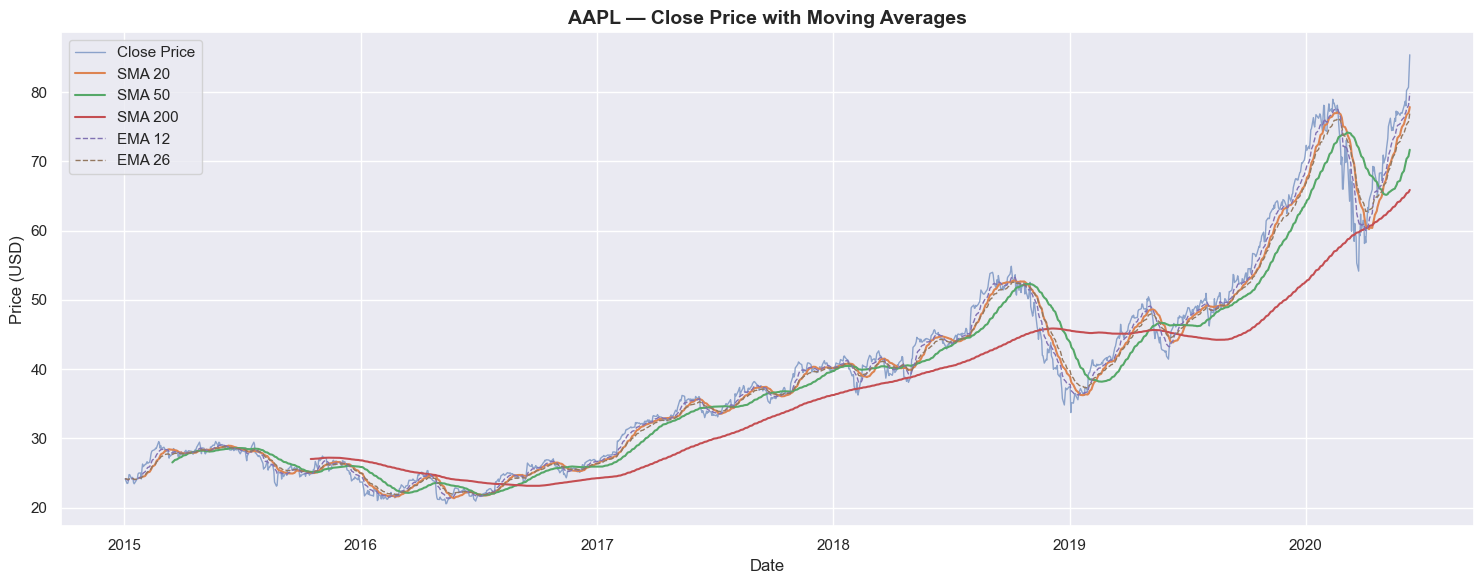

SMA and EMA computed successfully!


In [7]:
# Work with one stock at a time - let's use AAPL
ticker = 'AAPL'
df_stock = raw_data[ticker].copy()
df_stock = df_stock.dropna()

# Simple Moving Average (SMA)
df_stock['SMA_20'] = df_stock['Close'].rolling(window=20).mean()
df_stock['SMA_50'] = df_stock['Close'].rolling(window=50).mean()
df_stock['SMA_200'] = df_stock['Close'].rolling(window=200).mean()

# Exponential Moving Average (EMA)
df_stock['EMA_12'] = df_stock['Close'].ewm(span=12, adjust=False).mean()
df_stock['EMA_26'] = df_stock['Close'].ewm(span=26, adjust=False).mean()

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_stock.index, df_stock['Close'], label='Close Price', alpha=0.6, linewidth=1)
ax.plot(df_stock.index, df_stock['SMA_20'], label='SMA 20', linewidth=1.5)
ax.plot(df_stock.index, df_stock['SMA_50'], label='SMA 50', linewidth=1.5)
ax.plot(df_stock.index, df_stock['SMA_200'], label='SMA 200', linewidth=1.5)
ax.plot(df_stock.index, df_stock['EMA_12'], label='EMA 12', linestyle='--', linewidth=1)
ax.plot(df_stock.index, df_stock['EMA_26'], label='EMA 26', linestyle='--', linewidth=1)
ax.set_title(f'{ticker} — Close Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print('SMA and EMA computed successfully!')

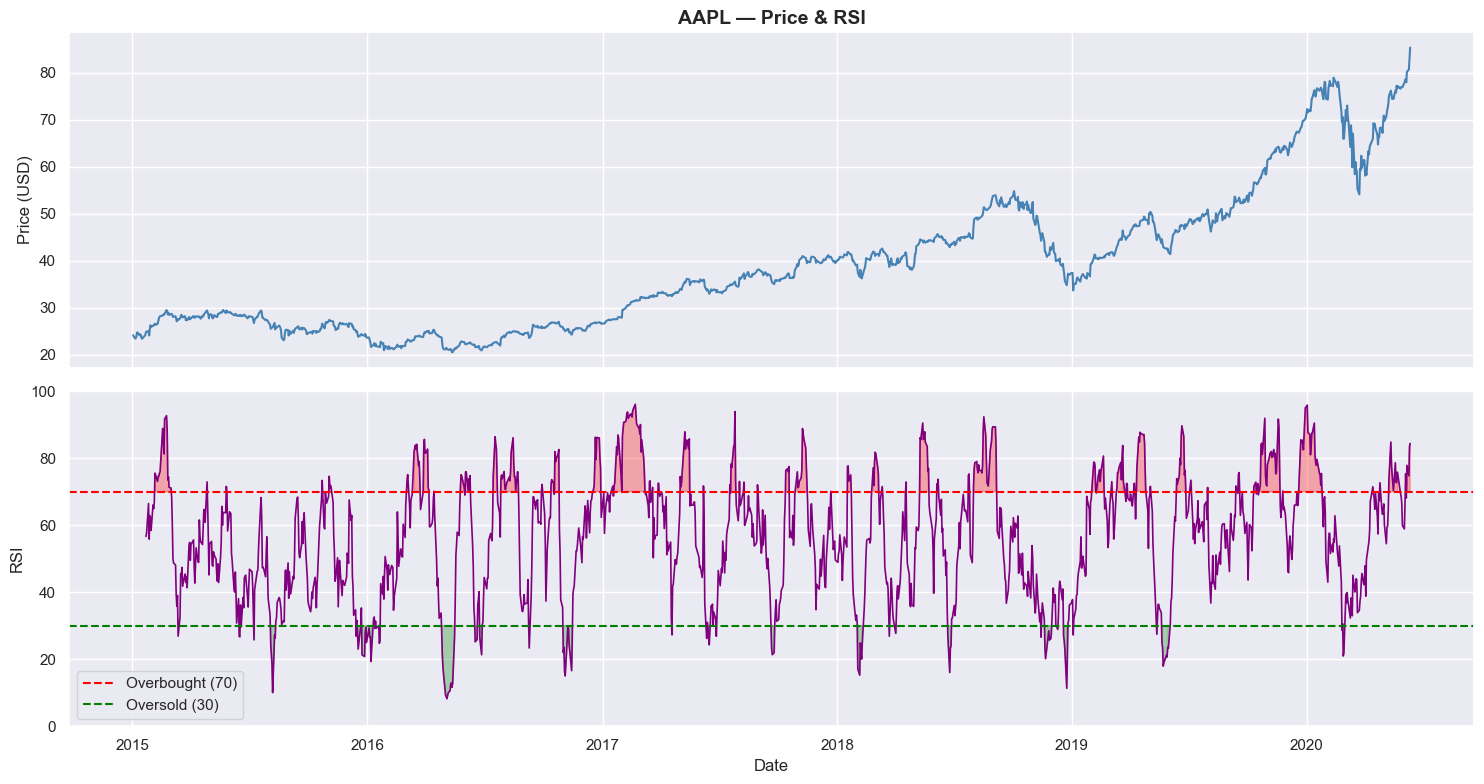

RSI computed successfully!


In [8]:
# Relative Strength Index (RSI)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_stock['RSI'] = compute_rsi(df_stock['Close'])

# Plot
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Price
axes[0].plot(df_stock.index, df_stock['Close'], color='steelblue', linewidth=1.5)
axes[0].set_title(f'{ticker} — Price & RSI', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

# RSI
axes[1].plot(df_stock.index, df_stock['RSI'], color='purple', linewidth=1.2)
axes[1].axhline(70, color='red', linestyle='--', label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[1].fill_between(df_stock.index, df_stock['RSI'], 70,
                     where=(df_stock['RSI'] >= 70), alpha=0.3, color='red')
axes[1].fill_between(df_stock.index, df_stock['RSI'], 30,
                     where=(df_stock['RSI'] <= 30), alpha=0.3, color='green')
axes[1].set_ylabel('RSI')
axes[1].set_xlabel('Date')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()
print('RSI computed successfully!')

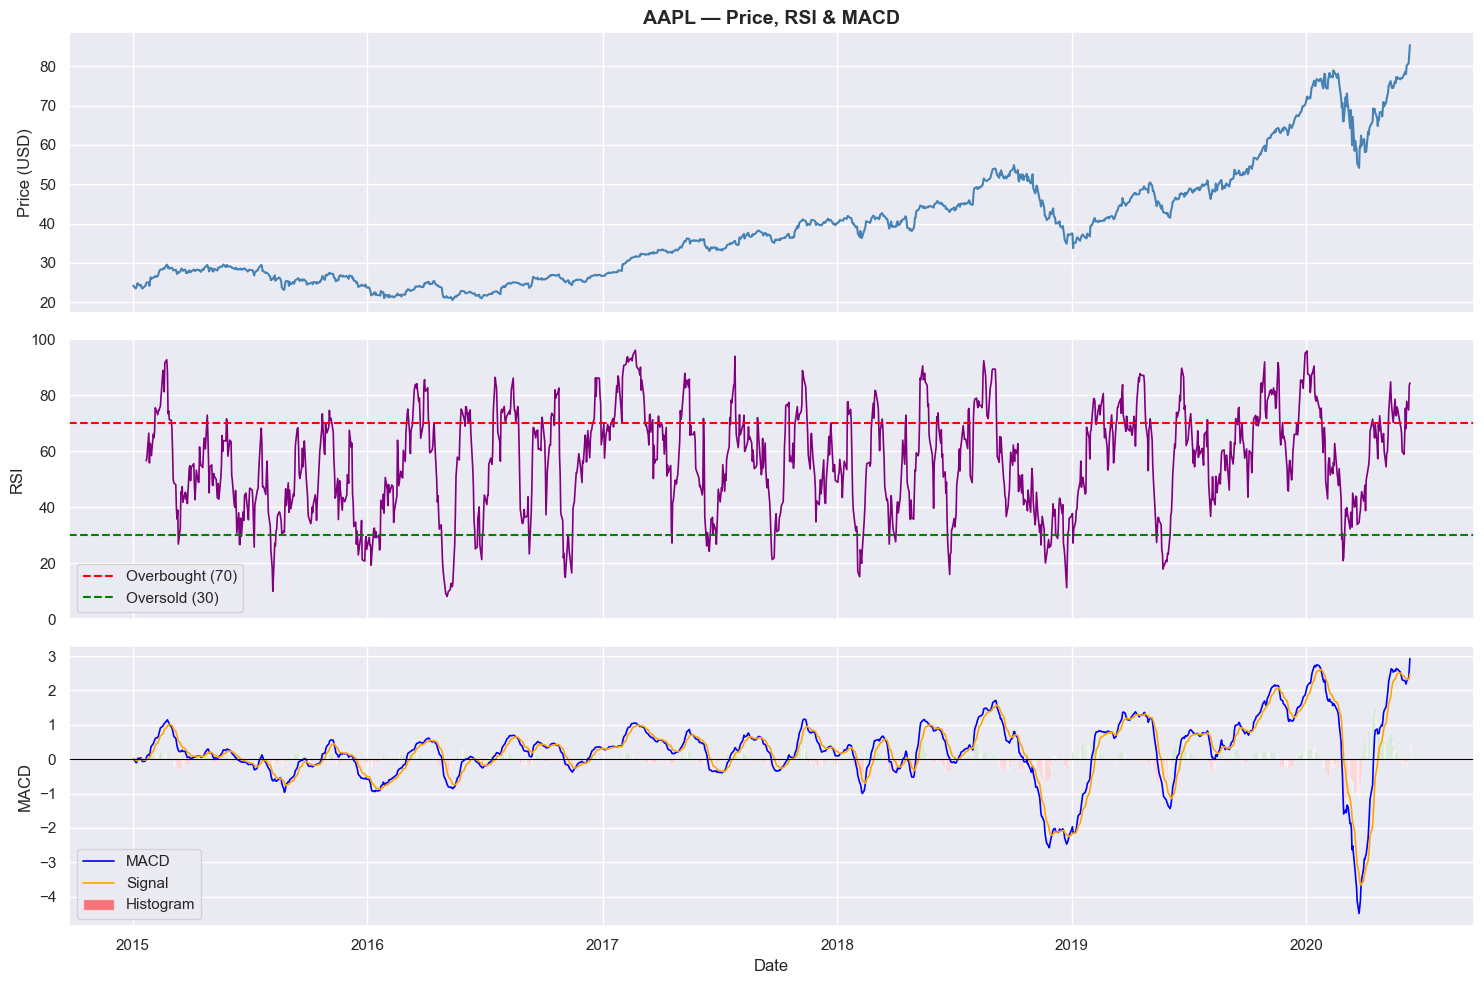

MACD computed successfully!


In [9]:
# MACD (Moving Average Convergence Divergence)
df_stock['MACD'] = df_stock['EMA_12'] - df_stock['EMA_26']
df_stock['Signal'] = df_stock['MACD'].ewm(span=9, adjust=False).mean()
df_stock['Histogram'] = df_stock['MACD'] - df_stock['Signal']

# Plot
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Price
axes[0].plot(df_stock.index, df_stock['Close'], color='steelblue', linewidth=1.5)
axes[0].set_title(f'{ticker} — Price, RSI & MACD', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

# RSI
axes[1].plot(df_stock.index, df_stock['RSI'], color='purple', linewidth=1.2)
axes[1].axhline(70, color='red', linestyle='--', label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend()

# MACD
axes[2].plot(df_stock.index, df_stock['MACD'], label='MACD', color='blue', linewidth=1.2)
axes[2].plot(df_stock.index, df_stock['Signal'], label='Signal', color='orange', linewidth=1.2)
axes[2].bar(df_stock.index, df_stock['Histogram'],
            color=df_stock['Histogram'].apply(lambda x: 'green' if x > 0 else 'red'),
            alpha=0.5, label='Histogram')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()
print('MACD computed successfully!')

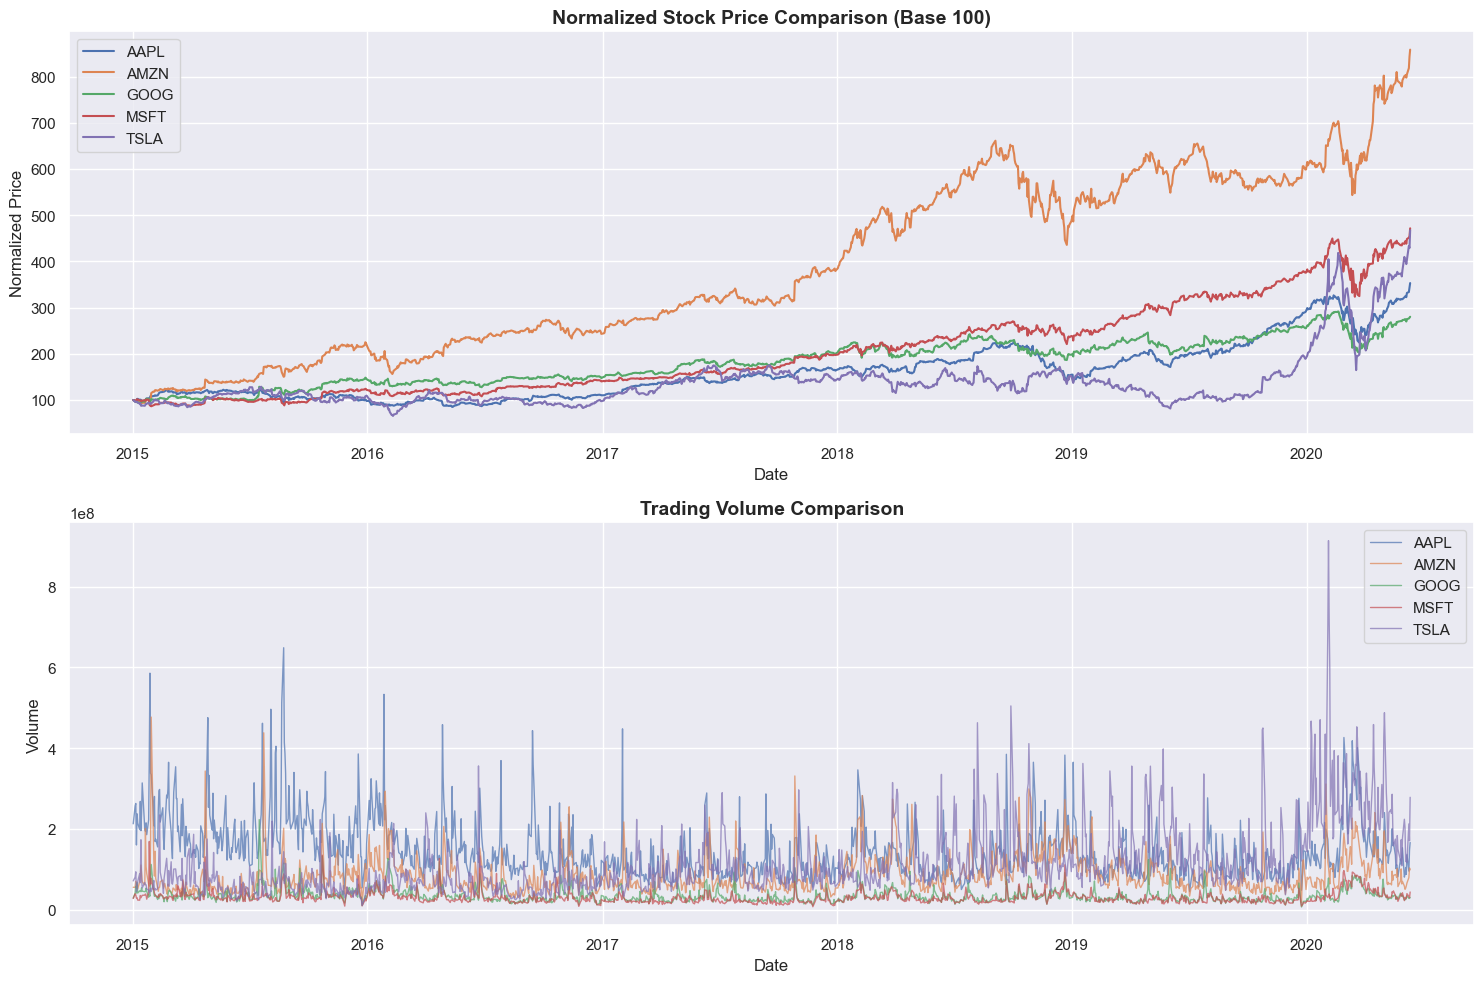

--- Summary Statistics (Close Price) ---
          AAPL     AMZN     GOOG     MSFT     TSLA
count  1369.00  1369.00  1369.00  1369.00  1369.00
mean     38.86    59.81    47.04    81.27    20.17
std      14.49    29.14    12.56    38.63     8.83
min      20.57    14.35    24.36    34.36     9.58
25%      26.60    34.84    36.69    47.62    14.91
50%      36.39    49.85    48.03    68.12    17.78
75%      46.94    88.09    57.01   104.23    22.15
max      85.41   132.37    75.71   187.50    68.34


In [10]:
# Compare all tickers - closing prices normalized
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Normalized price comparison (base 100)
for ticker in tickers:
    close = raw_data[ticker]['Close'].dropna()
    normalized = (close / close.iloc[0]) * 100
    axes[0].plot(normalized.index, normalized.values, label=ticker, linewidth=1.5)

axes[0].set_title('Normalized Stock Price Comparison (Base 100)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Normalized Price')
axes[0].set_xlabel('Date')
axes[0].legend()

# Volume comparison
for ticker in tickers:
    volume = raw_data[ticker]['Volume'].dropna()
    axes[1].plot(volume.index, volume.values, label=ticker, linewidth=1, alpha=0.7)

axes[1].set_title('Trading Volume Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary stats
print('--- Summary Statistics (Close Price) ---')
summary = pd.DataFrame({
    ticker: raw_data[ticker]['Close'].dropna().describe()
    for ticker in tickers
})
print(summary.round(2))